In [9]:
import os

import torch
import numpy as np
import pandas as pd


from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
os.environ["CUDA_VISIBLE_DEVICES"]="6"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Load raw Data

In [14]:
# Load the data generated by preprocess.py
df = pd.read_csv('./twitter-incremental-clustering/event2012.tsv', sep='\t')

# Display first few rows
# COLUMNS: id, text, created_at, label
print(f"Loaded {len(df)} tweets.")
df.head()

Loaded 68841 tweets.


,id,text,created_at,label
0,256292946331181056,Nobel prize in literature to be announced http...,2012-10-11 07:19:34,0
1,256333064467279872,“@marvicleonen: Is it true that UP won UAAP ba...,2012-10-11 09:58:59,0
2,256334302034399232,"Congrats, Ateneo! Last na yan ha. Season 76 wi...",2012-10-11 10:03:54,0
3,256335853738160128,"""@SMARTPromos: SMART never wants you to be lef...",2012-10-11 10:10:04,0
4,256346272506712064,CCTV invite hints at Nobel literature prize fo...,2012-10-11 10:51:28,0


# Load Embeddings

In [11]:
embeddings_raw = np.load('data/event2012_embeddings.npy')
# Convert to a Float Tensor & move to GPU
embeddings = torch.from_numpy(embeddings_raw).float().to(device)

# Load the metadata to track tweet IDs
metadata = pd.read_csv('data/event2012_metadata.csv')

print(f"Loaded {embeddings.shape[0]} embeddings with dimension {embeddings.shape[1]}")

Loaded 68841 embeddings with dimension 768


In [12]:
# 1. Run t-SNE on the pre-computed embeddings
# 'embeddings_raw' should be your (N, D) array on the CPU
print("Reducing Dimensions to 2D: Running t-SNE (this may take a few minutes)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
z_2d = tsne.fit_transform(embeddings_raw) 
print("Done! 'z_2d' is now ready.")

Reducing Dimensions to 2D: Running t-SNE (this may take a few minutes)...
Done! 'z_2d' is now ready.


In [19]:
labels = df['label'].unique()

# Create the colors and shuffle them ONCE with a fixed seed
colors = sns.color_palette("husl", len(labels))
np.random.seed(42)
np.random.shuffle(colors)

# Map each Ground Truth ID to a specific, permanent color
gt_color_dict = dict(zip(labels, colors))

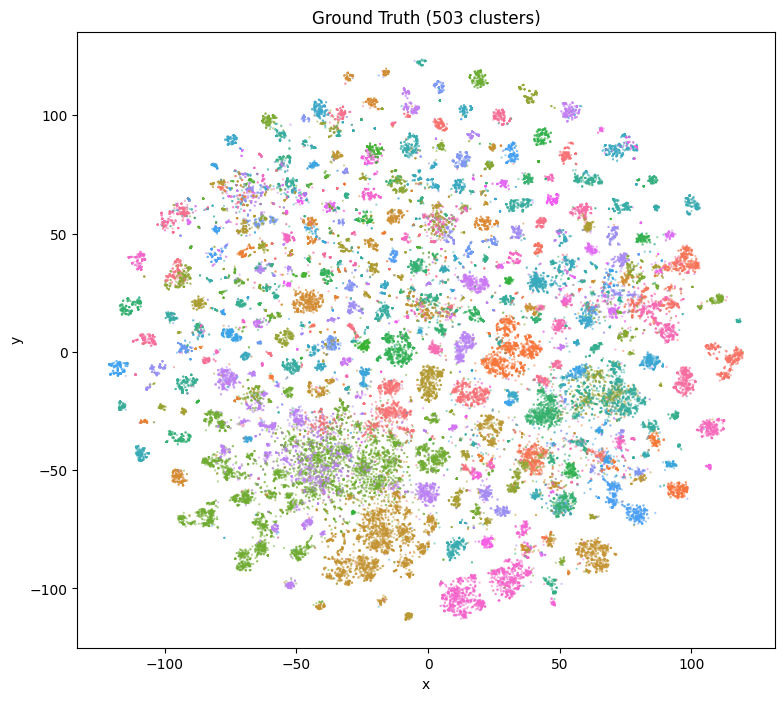

In [30]:
# 2. Visualize the Ground Truth
plt.figure(figsize=(9, 8))

# We use the 'label' column from your dataframe 'df' for the ground truth colors
# Using legend=False because 503 labels would overwhelm the plot
sns.scatterplot(
    x=z_2d[:, 0], 
    y=z_2d[:, 1], 
    hue=df['label'], 
    palette=gt_color_dict, 
    s=2,
    alpha=0.5,
    edgecolor=None,
    legend=False,
)

plt.title(f'Ground Truth ({len(labels)} clusters)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

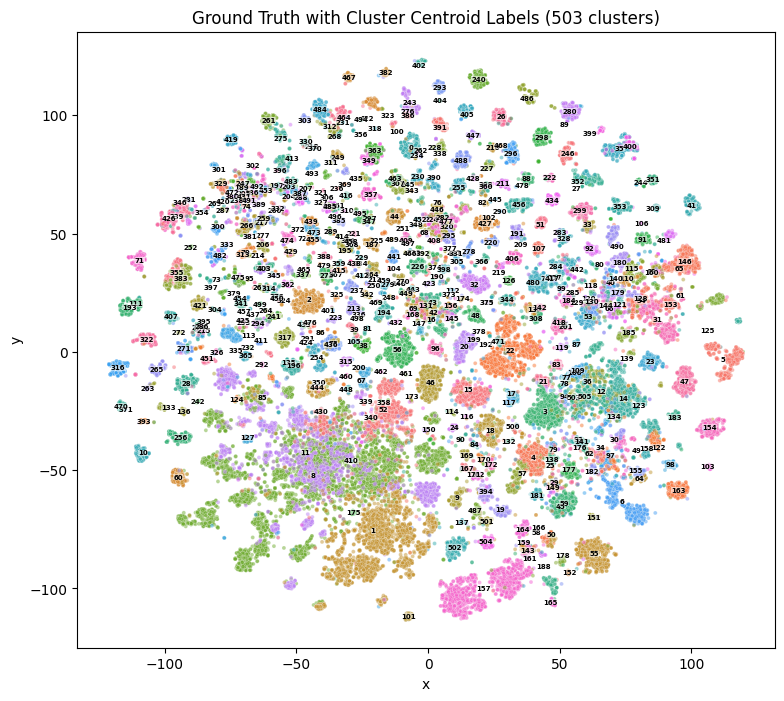

In [37]:
# Create the base plot
plt.figure(figsize=(9, 8))

# Pass in color dictionary for palette
sns.scatterplot(
    x=z_2d[:, 0], 
    y=z_2d[:, 1], 
    hue=df['label'], 
    palette=gt_color_dict, 
    legend=False, 
    alpha=0.5, 
    s=8
)

# Calculate and plot centroids
unique_labels = df['label'].unique()

for label in unique_labels:
    # Get indices for this specific ground truth cluster
    mask = (df['label'] == label)
    
    # Calculate the geometric center (centroid) of the t-SNE coordinates
    centroid_x = np.mean(z_2d[mask, 0])
    centroid_y = np.mean(z_2d[mask, 1])
    
    # Annotate the cluster ID at the centroid
    plt.text(
        centroid_x, 
        centroid_y, 
        str(label), 
        fontsize=5, 
        weight='bold',
        ha='center', 
        va='center',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.1)
    )

plt.title(f'Ground Truth with Cluster Centroid Labels ({len(labels)} clusters)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()